# Funciones de propiedades variables con la temperatura

En el proceso del modelado matemático del horno, se puede trabajar con los valores promedios de propiedades térmicas, pero es importante realizar la simulación de su comportamiento con las propiedades variables, y realizar la comparación con la simulacion de propiedades en valor promedio.

## Elementos de simulación

Dentro de los componentes de simulación, tenemos:

- Resistencia (Kanthal A1)
- Pieza (Acero A36)
- Termocupla (tipo K)
- Aire
- Ladrillo refractario aislante (Alta alumina)
- Fibra cerámica
- Lana de roca
- Plancha de acero

## Resistencia (Kanthal A1)

Considerando la ecuación que describe el comportamiento de la resistencia:
$$m_r\cdot c_r\cdot\frac{\partial{T_r}}{\partial{t}}=Q_{in}-Q_{out}$$
$$\rho_r\cdot V_r\cdot c_r\cdot\frac{\partial{T_r}}{\partial{t}}=P(t)-Q_{r\rightarrow 1}-Q_{r\rightarrow p}-Q_{r\rightarrow a}-Q_{r\rightarrow t}$$

$P(t)$ es la potencia de entrada, la cual es una función dependendiete del tiempo, controlado por el microcontrolador, a través de un relé.\
$Q_{r\rightarrow 1}$ es el calor transferido por radiación de la resistencia a la cara interna de las paredes (nodo 1).\
$Q_{r\rightarrow p}$ es el calor transferido por radiación de la resistencia a la pieza.\
$Q_{r\rightarrow a}$ es el calor transferido por convección de la resistencia a el aire.\
$Q_{r\rightarrow t}$ es el calor transferido por radiación de la resistencia a la termocupla.

Segun Electroheat(2017) para hornos de tratamiento térmico, desde los 600 °C hacia arriba, la forma de transferencia de calor es principalmente debido a la radiación. Y en Fundamentals of heat and mass transfer (2017) se refiere a cuerpos dentro un area cerrada, lo cual nos permite simplificar el area de los factores de visión ($F=1$), teniendo la ecuación final como:
$$\rho_r\cdot V_r\cdot c_r\cdot\frac{\partial{T_r}}{\partial{t}}=P(t)-Q_{r\rightarrow 1}-Q_{r\rightarrow p}-Q_{r\rightarrow t}$$
Siendo:\
$P(t)$ El perfil o la señal entrante resultante de la modulación del SSR.\
$$Q_{r\rightarrow 1}=\varepsilon_{r}\cdot\sigma\cdot A_r(T_{r}^4-T_{1}^4)$$
$$Q_{r\rightarrow p}=\varepsilon_{r}\cdot\sigma\cdot A_r(T_{r}^4-T_{p}^4)$$

En Fundamentals of heat and mass transfer (2017) habla de las superficies reradiantes, concepto que se usa mucho en el análisis de intercambio radiativo en recintos cerrados, porque permite simplificar cálculos: la superficie reradiante actúa como un “intermediario” que redistribuye la radiación entre otras superficies. En el caso del horno mufla, la superficie interna de ladrillo refractario es nuestra superficie rerradiante, por tanto la ecuación de la resistencia queda de la siguiente manera:
$$\rho_r\cdot V_r\cdot c_r\cdot\frac{\partial{T_r}}{\partial{t}}=P(t)-Q_{r\rightarrow w}$$
$$\rho_r\cdot V_r\cdot c_r\cdot\frac{\partial{T_r}}{\partial{t}}=P(t)-\varepsilon_{r}\cdot\sigma\cdot A_r(T_{r}^4-T_{1}^4)$$
$$\frac{\partial{T_r}}{\partial{t}}=\frac{P(t)}{\rho_r\cdot V_r\cdot c_r}-\frac{\varepsilon_{r}\cdot\sigma\cdot A_r(T_{r}^4-T_{1}^4)}{\rho_r\cdot V_r\cdot c_r}$$

Se puede observar que se está tomando la resistencia como un sistema de parámtros concentrados. Esto se justifica hallando el número de Biot de la resistencia:
$$Bi=\frac{h_{eff}\cdot L_c}{k}$$

Para que un sistema sea considerado como uno de parámetros concentrados, el numero de Biot debe ser menor a $0.1$, y por lo que se observa en la ecuación, este numero crecera si $h_{eff}$ crece. Si el coeficiente combinado varía con la temperatura, entonces, consideraremos el peor caso, para tener todas las probabilidades consideradas.

Hallamos $h_{eff}$ de la resistencia, el cual es el coeficiente global efectivo de la transferencia de calor en la superficie, inlcuida convección y radiación:
$$h_{eff}=h_{conv}+h_{rad}=h_{conv}+\varepsilon\sigma(T_{rs}+T_\infty)(T_{rs}^2+T_\infty^2)$$

Para las diferentes propiedades, tenemos los siguientes valores:\
$h_{conv}= 5 \text{ W m}^{-2} \text{K}^{-1}$, Segun Cengel(2012) para convección libre en gases (2 a 5).\
$\varepsilon=0.70$, Segun las hojas de datos de Kantal A1.\
$\sigma= 5.67 \times 10^{-8} \text{ W m}^{-2} \text{ K}^{-4}$, Constante de Stefan-Boltzmann.\
Tenemos:
Considerando un caso crítico, el cual es que la resistencia se encuentre a unos $1100 \text{ °C}$ y el entorno a $1000 \text{ °C}$.
$$h_{eff}=h_{conv}+h_{rad}=h_{conv}+\varepsilon\sigma(T_{rs}+T_\infty)(T_{rs}^2+T_\infty^2)$$
$$h_{eff}=5+0.7\times 5.67 \times 10^{-8}((1100+273.15)+(1000+273.15))((1100+273.15)^2+(1000+273.15)^2)$$
$$h_{eff}=373.3 \text{ W m}^{-2} \text{ K}^{-1}$$

Hallamos $L_c$, el cual es la longitud característica del cuerpo. Este se puede calcular dividiendo el volumen entre el area superficial.
$$L_c=\frac{V}{A_s}=\frac{\pi\cdot r^2\cdot h}{2\pi\cdot r\cdot h + 2\cdot\pi\cdot r^2}$$

Los datos con los que contamos son los siguientes:\
$r=0.9\times 10^{-3} \text{ m}$, Ya que el diametro de la resistencia es de $1.8 \text{ mm}$.\
$h=16.1 \text{ m} $, Cálculo del documento de proyecto de grado.\
Tenemos:
$$L_c=\frac{\pi\cdot r^2\cdot h}{2\pi\cdot r\cdot h + 2\pi\cdot r^2}$$
$$L_c=\frac{\pi\cdot (0.9\times 10^{-3})^2\cdot 16.1}{2\pi\cdot 0.9\times 10^{-3}\cdot 16.1 + 2\pi\cdot (0.9\times 10^{-3})^2}$$
$$L_c=4.5\times10^{-4}\text{ m}$$

Y para $k$ que es la conductividad térmica del material, contamos con los datos que nos brida el fabricante de Kantal A1.
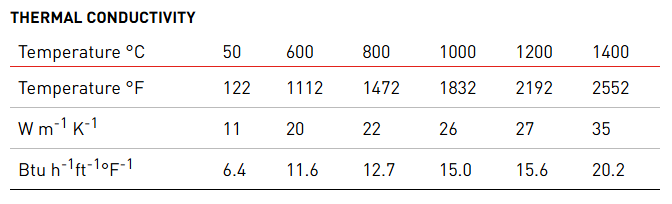\
Para las temperaturas elegidas cuando se calculó el $h_{eff}$, tenemos:
$$k=26\text{ W m}^{-1}\text{ K}^{-1}$$

Con los datos obtenidos se calcula el numero de Biot para la resistencia:
$$Bi=\frac{h_{eff}\cdot L_c}{k}$$
$$Bi=\frac{373.3 \text{ W m}^{-2} \text{ K}^{-1}\cdot 4.5\times10^{-4}\text{ m}}{26\text{ W m}^{-1}\text{ K}^{-1}}=0.0065$$
$$Bi=0.0065<0.1$$

Por lo que la suposición de la resistencia como un sistema de parámetros concentrados, es valida.

Para la resistencia, solo tenemos un valor que vaía con la temperatura relevante para un mejor control, el cual es el calor específico (datos brindados por el fabricante):
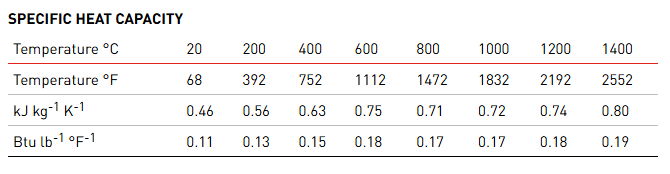

Con el siguiente Script hallamos la ecuación que describe la variación de $c_r$ y con el poder realizar una simulación mas cercana a la realidad.


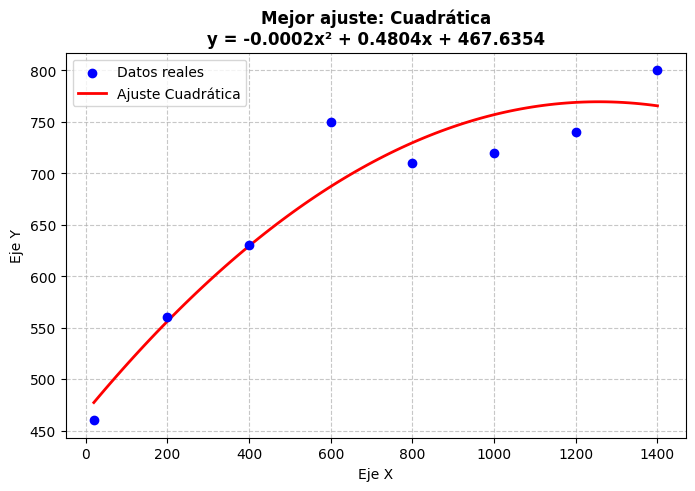

 El mejor modelo es: Cuadrática
 Ecuación: y = -0.0002x² + 0.4804x + 467.6354

 R^2 para cada modelo:
  - Lineal: 0.8078
  - Cuadrática: 0.9108
  - Exponencial: -inf


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings

# 1. Definimos las funciones matemáticas
def funcion_lineal(x, a, b):
    return a * x + b

def funcion_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c

def funcion_exponencial(x, a, b):
    return a * np.exp(b * x)

def calcular_r2(y_real, y_predicho):
    residuos = y_real - y_predicho
    suma_cuadrados_totales = np.sum((y_real - np.mean(y_real))**2)
    if suma_cuadrados_totales == 0: return 1.0
    return 1 - (np.sum(residuos**2) / suma_cuadrados_totales)

# Función para formatear la ecuación matemáticamente
def generar_ecuacion(nombre_modelo, coeficientes):
    if nombre_modelo == "Lineal":
        a, b = coeficientes
        return f"y = {a:.4f}x {'+' if b >= 0 else '-'} {abs(b):.4f}"
    
    elif nombre_modelo == "Cuadrática":
        a, b, c = coeficientes
        signo_b = '+' if b >= 0 else '-'
        signo_c = '+' if c >= 0 else '-'
        return f"y = {a:.4f}x² {signo_b} {abs(b):.4f}x {signo_c} {abs(c):.4f}"
    
    elif nombre_modelo == "Exponencial":
        a, b = coeficientes
        return f"y = {a:.4f} * e^({b:.4f}x)"
    
    return "Ecuación no disponible"

# 2. Función principal modificada
def analizar_y_graficar_datos(lista_x, lista_y):
    x = np.array(lista_x, dtype=float)
    y = np.array(lista_y, dtype=float)
    
    modelos = {
        "Lineal": funcion_lineal,
        "Cuadrática": funcion_cuadratica,
        "Exponencial": funcion_exponencial
    }
    
    resultados_r2 = {}
    mejor_modelo = None
    mejor_r2 = -float('inf')
    mejores_coeficientes = None
    mejor_funcion = None
    
    warnings.filterwarnings('ignore')
    
    for nombre, funcion in modelos.items():
        try:
            # Encontramos los coeficientes (popt)
            popt, _ = curve_fit(funcion, x, y, maxfev=10000)
            y_predicho = funcion(x, *popt)
            r2 = calcular_r2(y, y_predicho)
            resultados_r2[nombre] = r2
            
            # Guardamos el mejor modelo y sus coeficientes
            if r2 > mejor_r2:
                mejor_r2 = r2
                mejor_modelo = nombre
                mejores_coeficientes = popt
                mejor_funcion = funcion
                
        except Exception as e:
            resultados_r2[nombre] = "Error"
            
    warnings.filterwarnings('default')
    
    # Obtenemos la ecuación en texto
    ecuacion_texto = generar_ecuacion(mejor_modelo, mejores_coeficientes)
    
    # --- 3. SECCIÓN DE GRAFICADO ---
    plt.figure(figsize=(8, 5))
    
    # Graficamos los datos originales (Puntos)
    plt.scatter(x, y, color='blue', label='Datos reales', zorder=5)
    
    # Creamos un rango de X suave para dibujar la curva
    # Tomamos 100 puntos entre el valor mínimo y máximo de X
    x_suave = np.linspace(min(x), max(x), 100)
    y_suave = mejor_funcion(x_suave, *mejores_coeficientes)
    
    # Graficamos la curva de ajuste
    plt.plot(x_suave, y_suave, color='red', label=f'Ajuste {mejor_modelo}', linewidth=2)
    
    # Configuramos detalles del gráfico
    plt.title(f"Mejor ajuste: {mejor_modelo}\n{ecuacion_texto}", fontsize=12, fontweight='bold')
    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Mostramos el gráfico
    plt.show()
    
    return mejor_modelo, ecuacion_texto, resultados_r2


# Datos de prueba (Una función exponencial con un poco de "ruido")
datos_x = [20, 200, 400, 600, 800, 1000, 1200, 1400]
datos_y = [460, 560, 630, 750, 710, 720, 740, 800]

mejor_ajuste, ecuacion, detalles = analizar_y_graficar_datos(datos_x, datos_y)

print(f" El mejor modelo es: {mejor_ajuste}")
print(f" Ecuación: {ecuacion}")
print("\n R^2 para cada modelo:")
for modelo, r2 in detalles.items():
    if isinstance(r2, float):
        print(f"  - {modelo}: {r2:.4f}")
    else:
        print(f"  - {modelo}: {r2}")

Ahora calculamos el valor promedio de $c_r$ entre los valores de $20$ y $1000 \text{ °C}$, ya que es el rango en el que trabajará.

In [18]:
# 1. Definimos los datos entre el rango de temperatura
mis_datos = [460, 560, 630, 750, 710, 720]

# 2. Verificamos que la lista no esté vacía para evitar errores de división por cero
if len(mis_datos) > 0:
    # sum() suma todos los números, len() cuenta cuántos números hay
    promedio = sum(mis_datos) / len(mis_datos)
    
    print(f"Los datos son: {mis_datos}")
    print(f"El valor promedio es: {promedio:.2f}")
else:
    print("La lista está vacía, no se puede calcular el promedio.")

Los datos son: [460, 560, 630, 750, 710, 720]
El valor promedio es: 638.33


Por tanto, para la resistencia, tenemos las siguientes ecuaciónes y los siguientes datos:

$$\frac{\partial{T_r}}{\partial{t}}=\frac{P(t)}{\rho_r\cdot V_r\cdot c_r}-\frac{\varepsilon_{r}\cdot\sigma\cdot A_r(T_{r}^4-T_{1}^4)}{\rho_r\cdot V_r\cdot c_r}$$
$$\frac{\partial{T_r}}{\partial{t}}=\frac{1}{\rho_r\cdot V_r\cdot c_r}\cdot P(t)-\frac{\varepsilon_{r}\cdot\sigma\cdot A_r}{\rho_r\cdot V_r\cdot c_r}\cdot (T_{r}^4-T_{1}^4)$$

Con los datos que tenemos de la resistencia:\
$\rho_r=7100\text{ kg}\text{ cm}^{-3}$, Densidad del alambre (Hoja de datos de Kantal A1).\
$V_r=4.1\times 10^{-5}\text{ m}^3$, Volumen del alamabre (Calculado en el documento del proyecto).\
$\varepsilon_r=0.7$, Emisividad del alambre (Hoja de datos de Kantal A1).\
$\sigma= 5.67 \times 10^{-8} \text{ W m}^{-2} \text{ K}^{-4}$, Constante de Stefan-Boltzmann.\
$A_r=0.091 \text{ m}^2$, Es el area del alambrea (Calculado en el documento del proyecto).\
$c_r(T)=-0.0002T^2 + 0.4804T + 467.6354\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, El calor especifico en función de la temperatura.\
$c_{r-prom}=638\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, El calor específico promedio.

Se tiene, utilizando los valores promedio:

$$\frac{\partial{T_r}}{\partial{t}}=0.0054\cdot P(t)-1.94\times 10^{-11}\cdot (T_{r}^4-T_{1}^4)$$

Utilizando el calor especifico, dependiente de la temperatura:
$$\frac{\partial{T_r}}{\partial{t}}=\frac{3.44}{c_r(T)}\cdot P(t)-\frac{1.24\times 10^{-8}}{c_r(T)}\cdot (T_{r}^4-T_{1}^4)$$
$$c_r(T)=-0.0002T^2 + 0.4804T + 467.6354\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$$


## Pieza Acero A36
La ecuación que describe el comportamiento de la pieza es la siguiente:
$$m_p\cdot c_p\cdot\frac{dT_p}{dt}=Q_{in}-Q_{out}$$
$$\rho_p\cdot V_p\cdot c_p\cdot\frac{dT_p}{dt}=Q_{1\rightarrow p}$$

Donde:\
$Q_{1\rightarrow p}$, Es la energía transferida por radiación de las paredes a la pieza, considerando las suposiciones hechas en la parte de la resistencia.

Por tanto:
$$\rho_p\cdot V_p\cdot c_p\cdot\frac{dT_p}{dt}=\varepsilon_p\cdot\sigma\cdot A_p(T_1^4-T_p^4)$$
$$\frac{dT_p}{dt}=\frac{\varepsilon_p\cdot\sigma\cdot A_p}{\rho_p\cdot V_p\cdot c_p}\cdot(T_1^4-T_p^4)$$

Comprobamos si la pieza puede ser tratada como un sistema de parámetros concentrados, encontrando el numero de Biot:
$$Bi=\frac{h_{eff}\cdot L_c}{k}$$
Asi como se hizo en la resistencia, calculamos el $h_{eff}$ para la termocupla

$$h_{eff}=h_{conv}+h_{rad}=h_{conv}+\varepsilon\sigma(T_{ts}+T_\infty)(T_{ps}^2+T_\infty^2)$$
Para las diferentes propiedades, tenemos los siguientes valores:\
$h_{conv}= 5 \text{ W m}^{-2} \text{K}^{-1}$, Segun Cengel(2012) para convección libre en gases (2 a 5).\
$\varepsilon=0.11$, Segun Cengel(2017) para superficies de acero pulido.\
$\sigma= 5.67 \times 10^{-8} \text{ W m}^{-2} \text{ K}^{-4}$, Constante de Stefan-Boltzmann.\

Suponiendo un caso critico en el que las paredes y la pieza se encuentran a la misma temperatura de $1000\text{ °C}$
$$h_{eff}=5+0.11\cdot5.67\times 10^{-8}((1000+273.15)+(1000+273.15))((1000+273.15)^2+(1000+273.15)^2)$$
$$h_{eff}=56.5\text{ W m}^{-2} \text{ K}^{-1}$$

Para calcular $L_c$ la longitud característica:
$$L_c=\frac{V}{A_s}=\frac{\pi\cdot r^2\cdot h}{2\pi\cdot r^2+2\pi\cdot r\cdot h}$$

Los datos con los que contamos son los siguientes:\
$r=12.7\times 10^{-3} \text{ m}$, La mitad de una pulgada, que es el diametro de la probeta\
$h=0.03\text{ m}$ La altura promedio de las probetas.
Tenemos:
$$L_c=0.0045\text{ m}$$

Para el coeficiente de conducción de calor en el acero, tomamos un valor promedio:\
$k_{ac}=45\text{ W m}^{-1}\text{ K}^{-1}$, Valor extraido de Cengel(2017). 

Con los datos obtenidos se calcula el numero de Biot para la pieza:
$$Bi=\frac{h_{eff}\cdot L_c}{k}$$
$$Bi=\frac{56.5 \text{ W m}^{-2} \text{ K}^{-1}\cdot 0.0045\text{ m}}{45\text{ W m}^{-1}\text{ K}^{-1}}=0.0056$$
$$Bi=0.0056<0.1$$

Por lo que la suposición de la pieza como un sistema de parámetros concentrados, es valida. Y tenemos las siguientes ecuaciones:
$$\frac{dT_p}{dt}=\frac{\varepsilon_p\cdot\sigma\cdot A_p}{\rho_p\cdot V_p\cdot c_p}\cdot(T_1^4-T_p^4)$$

Donde:\
$\varepsilon_p=0.75$, Segun Cengel(2017) para acero al carbono.\
$\sigma= 5.67 \times 10^{-8} \text{ W m}^{-2} \text{ K}^{-4}$, Constante de Stefan-Boltzmann.\
$A_p=0.0034\text{ m}^2$, Area superficial de la pieza.\
$\rho_p=7833\text{ kg m}^{-3}$, Densidad del acero. (Cengel, 2012).\
$V_p=1.52\times10^{-5}\text{ m}^3$, Volumen de la pieza.\
$c_p=453\text{ J kg}^{-1}\text{ K}^{-1}$, Calor especifico del acero. (Cengel, 2012)

$$\frac{dT_p}{dt}=2.68\times10^{-12}(T_1^4-T_p^4)$$

Se debe considerar que la carga puede ser variable. Por tanto, las variables, que deben ser modificables son la masa $m_p=\rho_p\cdot V_p$ y el área al cual se irradia $A_p$.

En cuanto a la masa total se considera un coeficiente que se multiplicará a la masa de una probeta. En caso de que la cantidad de probetas cambie o la pieza ingresada al horno no cumpla con los parámetros de la probeta, entonces, en función de la masa se calcula el coeficiente mencionado.
$$C_{m}=\frac{masa total}{masa probeta}=\frac{masa total}{m_p}$$

Ahora con respecto al area donde se irradia, hay diversidad de formas de cargas, mas se tiene medidas de una probeta en especifico para el laboratorio, entonces nos guiamos con dicha forma, la cual es de un cilindro, y calcularemos el area suponiendo que la cantidad total de probetas forman un cilindro mas grande, con la misma altura de la probeta original.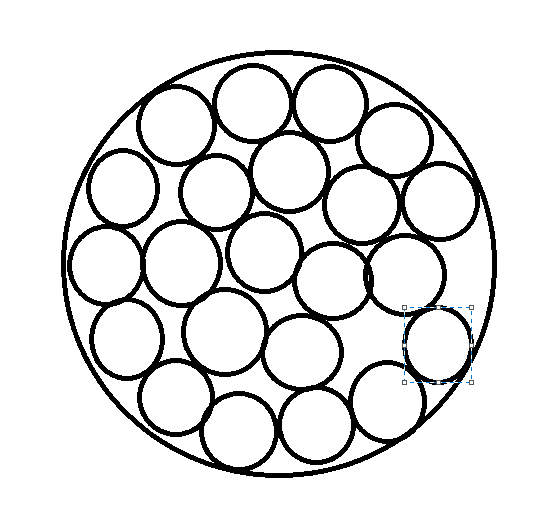

Entonces, con una masa dada, recalculamos el diametro del cilindro mas grande y con el, calculamos el area aproximada de la piezas que pueden ser irradiadas.
$$V_p=\frac{m_p}{\rho_p}\rightarrow\pi\cdot r^2\cdot h=\frac{m_p}{\rho_p}\rightarrow r=\sqrt{\frac{m_p}{\rho_p\cdot\pi\cdot h}}$$
$$A_p=2\pi\cdot r^2+2\pi\cdot r\cdot h$$
$$A_p=\frac{2\cdot m_p}{\rho_p\cdot h}+2\pi\cdot h\cdot \sqrt{\frac{m_p}{\rho_p\cdot\pi\cdot h}}$$

Por tanto la ecuación con masa variable para la pieza es:
$$\frac{dT_p}{dt}=\frac{\varepsilon_p\cdot\sigma}{\rho_p\cdot c_p}\cdot\frac{\rho_p}{m_p}\cdot\left(\frac{2\cdot m_p}{\rho_p\cdot h}+2\pi\cdot h\cdot \sqrt{\frac{m_p}{\rho_p\cdot\pi\cdot h}}\right)\cdot(T_1^4-T_p^4)$$
$$\frac{dT_p}{dt}=\left(\frac{2\cdot\varepsilon_p\cdot\sigma}{\rho_p\cdot c_p\cdot h}+\frac{2\cdot \varepsilon_p\cdot\sigma}{c_p}\cdot\sqrt{\frac{\pi\cdot h}{\rho_p\cdot m_p}}\right)\cdot(T_1^4-T_p^4)$$
$$\frac{dT_p}{dt}=\left(7.99\times10^{-13}+1.88\times10^{-10}\cdot0.0035\cdot\sqrt{\frac{1}{m_p}}\right)\cdot(T_1^4-T_p^4)$$
$$\frac{dT_p}{dt}=\left(7.99\times10^{-13}+6.57\times10^{-13}\cdot\sqrt{\frac{1}{m_p}}\right)\cdot(T_1^4-T_p^4)$$

## Termocupla

Considerando la ecuación que describe el comportamiento de la termocupla:
$$m_t\cdot c_t\cdot\frac{dT_t}{dt}=Q_{in}-Q_{out}$$
$$\rho_t\cdot V_t\cdot c_t\cdot\frac{dT_t}{dt}=Q_{1\rightarrow t}$$

Donde:\
$Q_{1\rightarrow t}$, Es la energía transferida por radiación de las paredes a la termocupla, considerando las suposiciones hechas en la parte de la resistencia.

Por tanto:
$$\rho_t\cdot V_t\cdot c_t\cdot\frac{dT_t}{dt}=\varepsilon_t\cdot\sigma\cdot A_t(T_1^4-T_t^4)$$
$$\frac{dT_t}{dt}=\frac{\varepsilon_t\cdot\sigma\cdot A_t}{\rho_t\cdot V_t\cdot c_t}\cdot(T_1^4-T_t^4)$$

Para el análisis dinámico, el sensor de temperatura (termocupla Tipo K) fue considerado como un elemento de ganancia unitaria con propiedades termofísicas constantes. De acuerdo con Doebelin (Measurement Systems), la masa térmica del cordón de soldadura es lo suficientemente pequeña para que las no linealidades del calor específico ($c_r$) no alteren significativamente la constante de tiempo nominal del instrumento. Adicionalmente, aplicando el principio de separación de escalas de tiempo descrito por Seborg et al. (Process Dynamics and Control), la constante de tiempo de una termocupla expuesta (del orden de 1 a 2 segundos) resulta ser al menos un orden de magnitud inferior a la constante de tiempo térmica del horno (decenas de minutos), permitiendo omitir la dinámica transitoria del sensor en la función de transferencia global sin pérdida de fidelidad en el diseño del controlador.

Se puede observar que se está tomando la termocupla como un sistema de parámtros concentrados. Esto se justifica hallando el número de Biot de la termocupla:
$$Bi=\frac{h_{eff}\cdot L_c}{k}$$

Asi como se hizo en la resistencia, calculamos el $h_{eff}$ para la termocupla

$$h_{eff}=h_{conv}+h_{rad}=h_{conv}+\varepsilon\sigma(T_{ts}+T_\infty)(T_{ts}^2+T_\infty^2)$$
Para las diferentes propiedades, tenemos los siguientes valores:\
$h_{conv}= 5 \text{ W m}^{-2} \text{K}^{-1}$, Segun Cengel(2012) para convección libre en gases (2 a 5).\
$\varepsilon=0.80$, Segun Incropera(2017) para superficies metalicas oxidadas.\
$\sigma= 5.67 \times 10^{-8} \text{ W m}^{-2} \text{ K}^{-4}$, Constante de Stefan-Boltzmann.\

Suponiendo un caso critico en el que las paredes y la termocupla se encuentran a la misma temperatura de $1000\text{ °C}$
$$h_{eff}=5+0.8\cdot5.67\times 10^{-8}((1000+273.15)+(1000+273.15))((1000+273.15)^2+(1000+273.15)^2)$$
$$h_{eff}=379.4\text{ W m}^{-2} \text{ K}^{-1}$$

Para calcular $L_c$ la longitud característica:
$$L_c=\frac{V}{A_s}=\frac{\frac{4}{3}\pi\cdot r^3}{4\pi\cdot r^2}=\frac{r}{3}=\frac{D}{6}$$

Los datos con los que contamos son los siguientes:\
$D=3\times 10^{-3} \text{ m}$, Ya que el diametro aproximado de la union de la termocupla.\
Tenemos:
$$L_c=5\times10^{-4}\text{ m}$$

Para $k$ de la termocupla, al ser una aleación entre Cromel y Alumel la conductividad térmica suele ser un promedio (Valores recopilados de [teii.mx](https://teii.mx/termopar-tipo-k-alumel-cromel/)):
$$k_{chromel}=19\text{ W}{ m}^{-1}\text{ K}^{-1}\text{ ; }k_{alumel}=30\text{ W}{ m}^{-1}\text{ K}^{-1}\text{ ; }k_{prom}=24.5\text{ W}{ m}^{-1}\text{ K}^{-1}$$

Para encontrar el valor promedio del calor específico de la termocupla tipo K, evaluamos de manera independiente cada metal ([metotechnics.com](https://metotechnics.com/hromel.htm)):\

Para el Chromel:
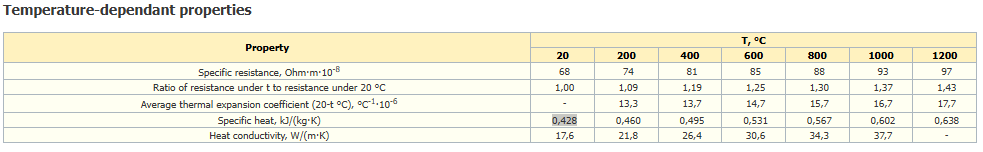
Encontramos el valor promedio


In [21]:
# 1. Definimos los datos entre el rango de temperatura
mis_datos = [428, 460, 495, 531, 567, 602]

# 2. Verificamos que la lista no esté vacía para evitar errores de división por cero
if len(mis_datos) > 0:
    # sum() suma todos los números, len() cuenta cuántos números hay
    promedio = sum(mis_datos) / len(mis_datos)
    
    print(f"Los datos son: {mis_datos}")
    print(f"El valor promedio es: {promedio:.2f}")
else:
    print("La lista está vacía, no se puede calcular el promedio.")

Los datos son: [428, 460, 495, 531, 567, 602]
El valor promedio es: 513.83


Para el Alumel:
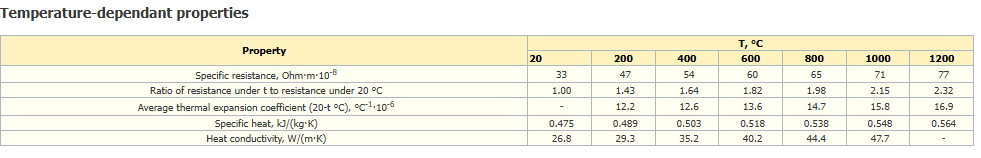

Encontramos el valor promedio

In [22]:
mis_datos = [475, 489, 503, 518, 538, 548]

# 2. Verificamos que la lista no esté vacía para evitar errores de división por cero
if len(mis_datos) > 0:
    # sum() suma todos los números, len() cuenta cuántos números hay
    promedio = sum(mis_datos) / len(mis_datos)
    
    print(f"Los datos son: {mis_datos}")
    print(f"El valor promedio es: {promedio:.2f}")
else:
    print("La lista está vacía, no se puede calcular el promedio.")

Los datos son: [475, 489, 503, 518, 538, 548]
El valor promedio es: 511.83



Con los datos obtenidos se calcula el numero de Biot para la termocupla:
$$Bi=\frac{h_{eff}\cdot L_c}{k}$$
$$Bi=\frac{379.4 \text{ W m}^{-2} \text{ K}^{-1}\cdot 5\times10^{-4}\text{ m}}{24.5\text{ W m}^{-1}\text{ K}^{-1}}=0.0077$$
$$Bi=0.0077<0.1$$

Por lo que la suposición de la termocupla como un sistema de parámetros concentrados, es valida. Y tenemos las siguientes ecuaciones:
$$\frac{dT_t}{dt}=\frac{\varepsilon_t\cdot\sigma\cdot A_t}{\rho_t\cdot V_t\cdot c_t}\cdot(T_1^4-T_t^4)$$

Donde:\
$\varepsilon_t=0.80$, Segun Incropera(2017) para superficies metalicas oxidadas.\
$\sigma= 5.67 \times 10^{-8} \text{ W m}^{-2} \text{ K}^{-4}$, Constante de Stefan-Boltzmann.\
$A_t=2.8\times 10^{-5}\text{ m}^2$, Area de la termocupla.\
$\rho_t=8555\text{ kg}\text{ m}^{-3}$, Densidad promedio entre Chromel y Alumel.\
$V_t=1.4\times 10^{-8}\text{ m}$, Volumen de la termocupla.\
$c_t=512.8\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, Valor promedio de calor especifico entre Alumel y Chromel.

Tenemos:
$$\frac{dT_t}{dt}=2.0679\times 10^{-11}(T_1^4-T_t^4)$$


## Aire

Para la formulación de las ecuaciones de balance de energía, se consideró la atmósfera interna del horno (aire) como un Medio No Participante. De acuerdo con la teoría de transferencia de calor radiativo (Incropera & DeWitt), los gases diatómicos simétricos como el $N_2$ y el $O_2$ son transparentes a la radiación térmica en distancias cortas, por lo que no absorben ni emiten energía radiante de forma significativa.

Dado que a temperaturas de austenización ($>800^\circ\text{C}$) el intercambio térmico está gobernado en más de un 95% por la radiación, se despreció el efecto de la convección natural del aire. Esto permite acoplar térmicamente los nodos sólidos (Pared, Resistencia, Pieza y Sensor) de manera directa mediante la ley de Stefan-Boltzmann, eliminando la dinámica de fluidos del aire del sistema de ecuaciones sin comprometer la precisión requerida para la sintonización del controlador PID.

## Paredes

En las paredes, lo que se realizo es la división en 5 nodos, siendo el nodo 1 la cara interior del horno y el nodo 5 la cara exterior.
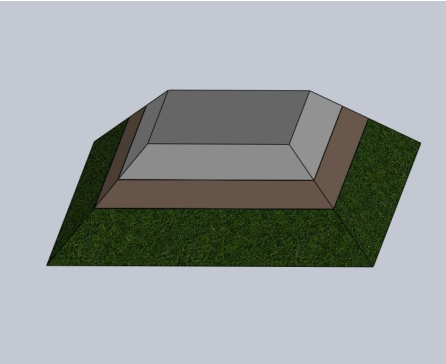\
Segun (Trinks, 2004), las conductividades y difusividades térmicas de los sólidos varían mucho con la temperatura. Los calores específicos y las densidades varían poco, excepto para los aceros en su punto de transición de fase. Las conductividades térmicas de los metales puros sólidos disminuyen al aumentar la temperatura, pero las conductividades de las aleaciones sólidas generalmente aumentan con la temperatura. Por esa razon solo tomaremos la conductividad como la propiedad que variará con la temperatura.

Por esta razon, solo contemplaremos como varian las conductividades con la temperatura.\
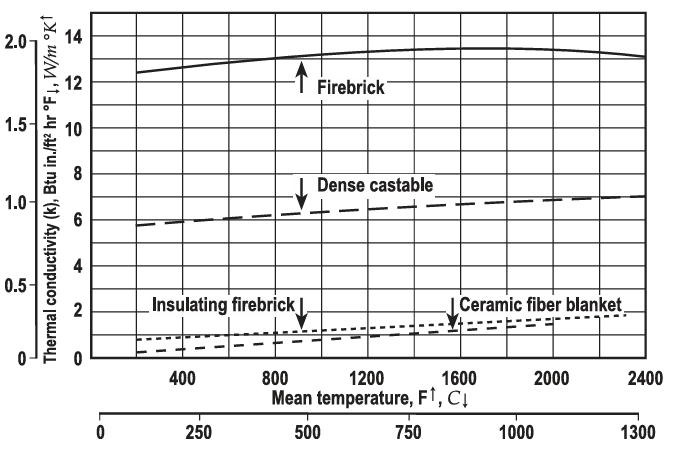
### Nodo 1 (Cara interior Ladrilo refractario aislante)
La ecuación que describe este nodo es el siguiente:
$$m_{lra}\cdot c_{lra}\cdot\frac{\partial T_{1}}{\partial t}=Q_{in}-Q_{out}$$
$$m_{lra}\cdot c_{lra}\cdot\frac{\partial T_{1}}{\partial t}=\varepsilon_r\cdot\sigma\cdot A_r(T_r^4-T_1^4)-\frac{k_{lra}\cdot A_{lra(prom)}}{\Delta x_{lra}}(T_1-T_2)-\varepsilon_t\cdot\sigma\cdot A_t(T_1^4-T_t^4)-\varepsilon_p\cdot\sigma\cdot A_p(T_1^4-T_p^4)$$
$$\frac{\partial T_{1}}{\partial t}=\frac{\varepsilon_r\cdot\sigma\cdot A_r}{\rho_{lra}\cdot A_{lra(prom)}\cdot \Delta x_{lra}/2\cdot c_{lra}}(T_r^4-T_1^4)-\frac{k_{lra}\cdot A_{lra(prom)}}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}^2/2}(T_1-T_2)-\frac{\varepsilon_t\cdot\sigma\cdot A_t}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}/2}(T_1^4-T_t^4)-\frac{\varepsilon_p\cdot\sigma\cdot A_p}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}/2}(T_1^4-T_p^4)$$

Calculamos el area y el volumen de la superficie del primer nodo (Datos extraidos del documento del proyecto de grado):\

Para el área a considerar, al ser cada lado una piramide truncada, calculamos el area promedio, siendo el area mas pequeña $A_i$ y el area mas grande $A_o$.
$$A_i=4(0.13\cdot 0.19) + 2(0.13\cdot 0.13)=0.13\text{ m}^2$$
$$A_o=4(0.18\cdot 0.24) + 2(0.18\cdot 0.18)=0.24\text{ m}^2$$
$$A_{lra(prom)}=\sqrt{A_i\cdot A_o}=\sqrt{0.13\cdot 0.24}=0.18\text{ m}^2$$

Y de los calculos realizados en el documento de proyecto de grado:\
$\Delta x_{lra}=0.025\text{ m}$, Es el espesor del ladrillo refractario aislante.

Para el ladrillo refractario aislante:

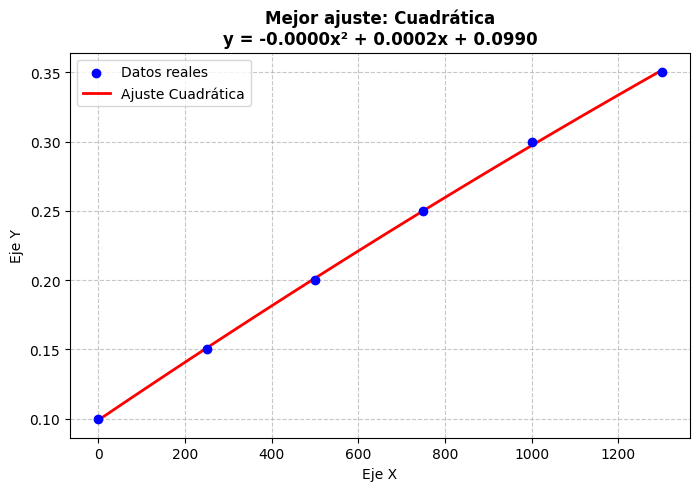

 El mejor modelo es: Cuadrática
 Ecuación: y = -0.0000x² + 0.0002x + 0.0990

 R^2 para cada modelo:
  - Lineal: 0.9990
  - Cuadrática: 0.9997
  - Exponencial: -inf


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings

# 1. Definimos las funciones matemáticas
def funcion_lineal(x, a, b):
    return a * x + b

def funcion_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c

def funcion_exponencial(x, a, b):
    return a * np.exp(b * x)

def calcular_r2(y_real, y_predicho):
    residuos = y_real - y_predicho
    suma_cuadrados_totales = np.sum((y_real - np.mean(y_real))**2)
    if suma_cuadrados_totales == 0: return 1.0
    return 1 - (np.sum(residuos**2) / suma_cuadrados_totales)

# Función para formatear la ecuación matemáticamente
def generar_ecuacion(nombre_modelo, coeficientes):
    if nombre_modelo == "Lineal":
        a, b = coeficientes
        return f"y = {a:.4f}x {'+' if b >= 0 else '-'} {abs(b):.4f}"
    
    elif nombre_modelo == "Cuadrática":
        a, b, c = coeficientes
        signo_b = '+' if b >= 0 else '-'
        signo_c = '+' if c >= 0 else '-'
        return f"y = {a:.4f}x² {signo_b} {abs(b):.4f}x {signo_c} {abs(c):.4f}"
    
    elif nombre_modelo == "Exponencial":
        a, b = coeficientes
        return f"y = {a:.4f} * e^({b:.4f}x)"
    
    return "Ecuación no disponible"

# 2. Función principal modificada
def analizar_y_graficar_datos(lista_x, lista_y):
    x = np.array(lista_x, dtype=float)
    y = np.array(lista_y, dtype=float)
    
    modelos = {
        "Lineal": funcion_lineal,
        "Cuadrática": funcion_cuadratica,
        "Exponencial": funcion_exponencial
    }
    
    resultados_r2 = {}
    mejor_modelo = None
    mejor_r2 = -float('inf')
    mejores_coeficientes = None
    mejor_funcion = None
    
    warnings.filterwarnings('ignore')
    
    for nombre, funcion in modelos.items():
        try:
            # Encontramos los coeficientes (popt)
            popt, _ = curve_fit(funcion, x, y, maxfev=10000)
            y_predicho = funcion(x, *popt)
            r2 = calcular_r2(y, y_predicho)
            resultados_r2[nombre] = r2
            
            # Guardamos el mejor modelo y sus coeficientes
            if r2 > mejor_r2:
                mejor_r2 = r2
                mejor_modelo = nombre
                mejores_coeficientes = popt
                mejor_funcion = funcion
                
        except Exception as e:
            resultados_r2[nombre] = "Error"
            
    warnings.filterwarnings('default')
    
    # Obtenemos la ecuación en texto
    ecuacion_texto = generar_ecuacion(mejor_modelo, mejores_coeficientes)
    
    # --- 3. SECCIÓN DE GRAFICADO ---
    plt.figure(figsize=(8, 5))
    
    # Graficamos los datos originales (Puntos)
    plt.scatter(x, y, color='blue', label='Datos reales', zorder=5)
    
    # Creamos un rango de X suave para dibujar la curva
    # Tomamos 100 puntos entre el valor mínimo y máximo de X
    x_suave = np.linspace(min(x), max(x), 100)
    y_suave = mejor_funcion(x_suave, *mejores_coeficientes)
    
    # Graficamos la curva de ajuste
    plt.plot(x_suave, y_suave, color='red', label=f'Ajuste {mejor_modelo}', linewidth=2)
    
    # Configuramos detalles del gráfico
    plt.title(f"Mejor ajuste: {mejor_modelo}\n{ecuacion_texto}", fontsize=12, fontweight='bold')
    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Mostramos el gráfico
    plt.show()
    
    return mejor_modelo, ecuacion_texto, resultados_r2


# Datos de prueba (Una función exponencial con un poco de "ruido")
datos_x = [0, 250, 500, 750, 1000, 1300]
datos_y = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]

mejor_ajuste, ecuacion, detalles = analizar_y_graficar_datos(datos_x, datos_y)

print(f" El mejor modelo es: {mejor_ajuste}")
print(f" Ecuación: {ecuacion}")
print("\n R^2 para cada modelo:")
for modelo, r2 in detalles.items():
    if isinstance(r2, float):
        print(f"  - {modelo}: {r2:.4f}")
    else:
        print(f"  - {modelo}: {r2}")

Y para el valor promedio:

In [4]:
mis_datos = [0.10, 0.15, 0.20, 0.25, 0.30]

# 2. Verificamos que la lista no esté vacía para evitar errores de división por cero
if len(mis_datos) > 0:
    # sum() suma todos los números, len() cuenta cuántos números hay
    promedio = sum(mis_datos) / len(mis_datos)
    
    print(f"Los datos son: {mis_datos}")
    print(f"El valor promedio es: {promedio:.2f}")
else:
    print("La lista está vacía, no se puede calcular el promedio.")

Los datos son: [0.1, 0.15, 0.2, 0.25, 0.3]
El valor promedio es: 0.20


Se puede observar que con un ajuste lineal es suficientemente aproximado.
Con todos estos datos podemos tener las ecuaciones con valores promedio, y la que varía con la temperatura.
$$\frac{\partial T_{1}}{\partial t}=\frac{2\cdot\varepsilon_r\cdot\sigma\cdot A_r}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}}(T_r^4-T_1^4)-\frac{2\cdot k_{lra}}{\rho_{lra}\cdot c_{lra}\cdot\Delta x_{lra}^2}(T_1-T_2)-\frac{2\cdot\varepsilon_t\cdot\sigma\cdot A_t}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}}(T_1^4-T_t^4)-\frac{2\cdot\varepsilon_p\cdot\sigma\cdot A_p}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}}(T_1^4-T_p^4)$$


Los datos de la densidad y del calor específico los tomamos de una hoja de datos de [refrattarigenerali.com](https://www.refrattarigenerali.com/attachments/JM262830.pdf)

$\varepsilon_r=0.7$, La emisividad de la resistencia.\
$\sigma=5.67\times 10^{-8}\text{ W m}^2\text{ K}^{-4}$, Constante de Stefan Boltzmann.\
$A_r=0.091\text{ m}^2$, Area de la resistencia que emite el calor.\
$A_{lra(prom)}=0.18\text{ m}^2$, Area promedio del material dentro el nodo examinado.\
$\rho_{lra}=770\text{ kg}\text{ m}^{-3}$, Densidad del ladrillo refractario aislante.\
$c_{lra}=1070\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, Calor específico del ladrillo refractario aislante.\
$\Delta x_{lra}=0.025\text{ m}$, Espesor del ladrillo refractario aislante.\
$\varepsilon_t=0.80$, Segun Incropera(2017) para superficies metalicas oxidadas.\
$A_t=2.8\times 10^{-5}\text{ m}^2$, Area de la termocupla.\
$\varepsilon_p=0.75$, Segun Cengel(2017) para superficies de acero pulido.\
$A_p=0.0034\text{ m}^2$, Area superficial de la pieza.\
$k_{lra(prom)}=0.20\text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica promedio del ladrillo refractario aislante.\
$k_{lra}(T)=0.0002T+0.0990 \text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica en función de la temperatura del ladrillo refractario aislante.


Con valores promedio:
$$\frac{\partial T_{1}}{\partial t}=1.95\times 10^{-12}(T_r^4-T_1^4)-7.77\times 10^{-4}(T_1-T_2)-6.85\times10^{-16}(T_1^4-T_t^4)-7.80\times10^{-14}(T_1^4-T_p^4)$$

Con la conductividad en función del temperatura:

$$\frac{\partial T_{1}}{\partial t}=1.95\times 10^{-12}(T_r^4-T_1^4)-0.0039\cdot k_{lra}(T)(T_1-T_2)-6.85\times10^{-16}(T_1^4-T_t^4)-7.80\times10^{-14}(T_1^4-T_p^4)$$
$$k_{lra}(T)=0.0002T+0.0990$$

Cuando una masa es variable, tambíen se debe modificar la ecuación presentada en este apartado, en especial el térmico que involucra la carga.
$$\frac{2\cdot\varepsilon_p\cdot\sigma\cdot A_p}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}}(T_1^4-T_p^4)$$

Para esta ecuación lo único que cambia es la parte del área irradiada:
$$A_p=\frac{2\cdot m_p}{\rho_p\cdot h}+2\pi\cdot h\cdot \sqrt{\frac{m_p}{\rho_p\cdot\pi\cdot h}}$$
Por tanto:
$$\frac{2\cdot\varepsilon_p\cdot\sigma}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}}\cdot\left(\frac{2\cdot m_p}{\rho_p\cdot h}+2\pi\cdot h\cdot \sqrt{\frac{m_p}{\rho_p\cdot\pi\cdot h}}\right) \cdot(T_1^4-T_p^4)$$
$$\left(1.95\times10^{-13}\cdot m_p+1.59\times10^{-13}\cdot \sqrt{m_p}\right) \cdot(T_1^4-T_p^4)$$

Siendo la ecuación final, considerando cambios en la masa de la carga y de la conductividad térmica:
$$\frac{\partial T_{1}}{\partial t}=1.95\times 10^{-12}(T_r^4-T_1^4)-0.0039\cdot k_{lra}(T)(T_1-T_2)-6.85\times10^{-16}(T_1^4-T_t^4)-\left(1.95\times10^{-13}\cdot m_p+1.59\times10^{-13}\cdot \sqrt{m_p}\right) \cdot(T_1^4-T_p^4)$$
$$k_{lra}(T)=0.0002T+0.0990$$

### Nodo 2 (Intefaz ladrillo aislante refractario y fibra cerámica)

La ecuación que describe este nodo es:
$$(m_{lra}\cdot c_{lra}\cdot + m_{fc}\cdot c_{fc})\frac{\partial{T_2}}{\partial{t}}=\frac{k_{lra}\cdot A_{lra(prom)}}{\Delta x_{lra}}(T_1-T_2)-\frac{k_fc\cdot A_{fc(prom)}}{\Delta x_{fc}}(T_2-T_3)$$
$$\frac{\partial{T_2}}{\partial{t}}=\frac{k_{lra}\cdot A_{lra(prom)}}{\Delta x_{lra}(\rho_{lra}\cdot A_{lra(prom)}\cdot\Delta x_{lra}/2\cdot c_{lra}\cdot + \rho_{fc}\cdot A_{fc(prom)}\cdot \Delta x_{fc}/2\cdot c_{fc})}(T_1-T_2)-\frac{k_fc\cdot A_{fc(prom)}}{\Delta x_{fc}(\rho_{lra}\cdot A_{lra(prom)}\cdot\Delta x_{lra}/2\cdot c_{lra}\cdot + \rho_{fc}\cdot A_{fc(prom)}\cdot \Delta x_{fc}/2\cdot c_{fc})}(T_2-T_3)$$
$$\frac{\partial{T_2}}{\partial{t}}=\frac{2\cdot k_{lra}\cdot A_{lra(prom)}}{\rho_{lra}\cdot A_{lra(prom)}\cdot\Delta x_{lra}^2\cdot c_{lra}\cdot + \rho_{fc}\cdot A_{fc(prom)}\cdot \Delta x_{fc}\cdot \Delta x_{lra}\cdot c_{fc}}(T_1-T_2)-\frac{2\cdot k_fc\cdot A_{fc(prom)}}{\rho_{lra}\cdot A_{lra(prom)}\cdot\Delta x_{lra}\cdot\Delta x_{fc}\cdot c_{lra}\cdot + \rho_{fc}\cdot A_{fc(prom)}\cdot \Delta x_{fc}^2\cdot c_{fc}}(T_2-T_3)$$

Calculamos las areas promedio para la fibra cerámica, ya que el del ladrillo refractario aislante, ya fue calculado:
$$A_{i}=4(0.18\cdot 0.24) + 2(0.18\cdot 0.18)=0.24\text{ m}^2$$
$$A_{o}=4(0.22\cdot 0.28) + 2(0.22\cdot 0.22)=0.34\text{ m}^2$$
$$A_{fc(prom)}=\sqrt{A_i\cdot A_o}=\sqrt{0.24\cdot 0.34}=0.28\text{ m}^2$$

Y de los calculos realizados en el documento de proyecto de grado:\
$\Delta x_{fc}=0.020\text{ m}$, Es el espesor del ladrillo refractario aislante.

Para la fibra cerámica:

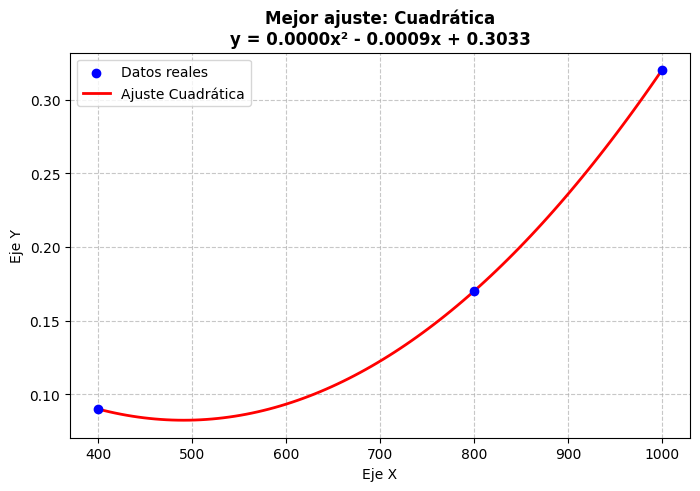

 El mejor modelo es: Cuadrática
 Ecuación: y = 0.0000x² - 0.0009x + 0.3033

 R^2 para cada modelo:
  - Lineal: 0.8732
  - Cuadrática: 1.0000
  - Exponencial: -inf


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings

# 1. Definimos las funciones matemáticas
def funcion_lineal(x, a, b):
    return a * x + b

def funcion_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c

def funcion_exponencial(x, a, b):
    return a * np.exp(b * x)

def calcular_r2(y_real, y_predicho):
    residuos = y_real - y_predicho
    suma_cuadrados_totales = np.sum((y_real - np.mean(y_real))**2)
    if suma_cuadrados_totales == 0: return 1.0
    return 1 - (np.sum(residuos**2) / suma_cuadrados_totales)

# Función para formatear la ecuación matemáticamente
def generar_ecuacion(nombre_modelo, coeficientes):
    if nombre_modelo == "Lineal":
        a, b = coeficientes
        return f"y = {a:.4f}x {'+' if b >= 0 else '-'} {abs(b):.4f}"
    
    elif nombre_modelo == "Cuadrática":
        a, b, c = coeficientes
        signo_b = '+' if b >= 0 else '-'
        signo_c = '+' if c >= 0 else '-'
        return f"y = {a:.4f}x² {signo_b} {abs(b):.4f}x {signo_c} {abs(c):.4f}"
    
    elif nombre_modelo == "Exponencial":
        a, b = coeficientes
        return f"y = {a:.4f} * e^({b:.4f}x)"
    
    return "Ecuación no disponible"

# 2. Función principal modificada
def analizar_y_graficar_datos(lista_x, lista_y):
    x = np.array(lista_x, dtype=float)
    y = np.array(lista_y, dtype=float)
    
    modelos = {
        "Lineal": funcion_lineal,
        "Cuadrática": funcion_cuadratica,
        "Exponencial": funcion_exponencial
    }
    
    resultados_r2 = {}
    mejor_modelo = None
    mejor_r2 = -float('inf')
    mejores_coeficientes = None
    mejor_funcion = None
    
    warnings.filterwarnings('ignore')
    
    for nombre, funcion in modelos.items():
        try:
            # Encontramos los coeficientes (popt)
            popt, _ = curve_fit(funcion, x, y, maxfev=10000)
            y_predicho = funcion(x, *popt)
            r2 = calcular_r2(y, y_predicho)
            resultados_r2[nombre] = r2
            
            # Guardamos el mejor modelo y sus coeficientes
            if r2 > mejor_r2:
                mejor_r2 = r2
                mejor_modelo = nombre
                mejores_coeficientes = popt
                mejor_funcion = funcion
                
        except Exception as e:
            resultados_r2[nombre] = "Error"
            
    warnings.filterwarnings('default')
    
    # Obtenemos la ecuación en texto
    ecuacion_texto = generar_ecuacion(mejor_modelo, mejores_coeficientes)
    
    # --- 3. SECCIÓN DE GRAFICADO ---
    plt.figure(figsize=(8, 5))
    
    # Graficamos los datos originales (Puntos)
    plt.scatter(x, y, color='blue', label='Datos reales', zorder=5)
    
    # Creamos un rango de X suave para dibujar la curva
    # Tomamos 100 puntos entre el valor mínimo y máximo de X
    x_suave = np.linspace(min(x), max(x), 100)
    y_suave = mejor_funcion(x_suave, *mejores_coeficientes)
    
    # Graficamos la curva de ajuste
    plt.plot(x_suave, y_suave, color='red', label=f'Ajuste {mejor_modelo}', linewidth=2)
    
    # Configuramos detalles del gráfico
    plt.title(f"Mejor ajuste: {mejor_modelo}\n{ecuacion_texto}", fontsize=12, fontweight='bold')
    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Mostramos el gráfico
    plt.show()
    
    return mejor_modelo, ecuacion_texto, resultados_r2


# Datos de prueba (Una función exponencial con un poco de "ruido")
datos_x = [400, 800, 1000]
datos_y = [0.09, 0.17, 0.32]

mejor_ajuste, ecuacion, detalles = analizar_y_graficar_datos(datos_x, datos_y)

print(f" El mejor modelo es: {mejor_ajuste}")
print(f" Ecuación: {ecuacion}")
print("\n R^2 para cada modelo:")
for modelo, r2 in detalles.items():
    if isinstance(r2, float):
        print(f"  - {modelo}: {r2:.4f}")
    else:
        print(f"  - {modelo}: {r2}")

Y para el valor promedio

In [7]:
mis_datos = [0.07, 0.13, 0.18, 0.25, 0.32]

# 2. Verificamos que la lista no esté vacía para evitar errores de división por cero
if len(mis_datos) > 0:
    # sum() suma todos los números, len() cuenta cuántos números hay
    promedio = sum(mis_datos) / len(mis_datos)
    
    print(f"Los datos son: {mis_datos}")
    print(f"El valor promedio es: {promedio:.2f}")
else:
    print("La lista está vacía, no se puede calcular el promedio.")

Los datos son: [0.07, 0.13, 0.18, 0.25, 0.32]
El valor promedio es: 0.19


Se puede observar que con un ajuste lineal es suficientemente aproximado. Con todos estos datos podemos tener las ecuaciones con valores promedio, y la que varía con la temperatura.
$$\frac{\partial{T_2}}{\partial{t}}=\frac{2\cdot k_{lra}\cdot A_{lra(prom)}}{\rho_{lra}\cdot A_{lra(prom)}\cdot\Delta x_{lra}^2\cdot c_{lra} + \rho_{fc}\cdot A_{fc(prom)}\cdot \Delta x_{fc}\cdot \Delta x_{lra}\cdot c_{fc}}(T_1-T_2)-\frac{2\cdot k_{fc}\cdot A_{fc(prom)}}{\rho_{lra}\cdot A_{lra(prom)}\cdot\Delta x_{lra}\cdot\Delta x_{fc}\cdot c_{lra} + \rho_{fc}\cdot A_{fc(prom)}\cdot \Delta x_{fc}^2\cdot c_{fc}}(T_2-T_3)$$

Los datos de la densidad y el calor específico de la fibra cerámica fueron extraidos de [ceramaterials.com](https://www.ceramaterials.com/wp-content/uploads/2021/01/CeramicBlanket-TDS-3000PCW-CM.pdf) y de los documentos de compra del material.

$\rho_{lra}=770\text{ kg}\text{ m}^{-3}$, Densidad del ladrillo refractario aislante.\
$A_{lra(prom)}=0.18\text{ m}^2$, Area promedio del material dentro el nodo examinado, por parte del ladrillo refractario aislante.\
$\Delta x_{lra}=0.025\text{ m}$, Espesor del ladrillo refractario aislante.\
$c_{lra}=1070\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, Calor específico del ladrillo refractario aislante.\
$\rho_{fc}=260\text{ kg}\text{ m}^{-3}$, Densidad de la fibra cerámica.\
$A_{fc(prom)}=0.28\text{ m}^2$, Area promedio del material dentro el nodo examinado, por parte de la fibra cerámica.\
$\Delta x_{fc}=0.020\text{ m}$, Espesor de la fibra cerámica.\
$c_{fc}=1246\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, Calor específico de la fibra cerámica.\
$k_{lra(prom)}=0.20\text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica promedio del ladrillo refractario aislante.\
$k_{lra}(T)=0.0002T+0.0990 \text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica en función de la temperatura del ladrillo refractario aislante.\
$k_{fc(prom)}=0.19\text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica promedio de la fibra cerámica.\
$k_{fc}(T)=0.0002T+0.0160 \text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica en función de la temperatura del ladrillo refractario aislante.

Con los valores promedio:
$$\frac{\partial{T_2}}{\partial{t}}=5.22\times 10^{-4}(T_1-T_2)-9.63\times 10^{-4}(T_2-T_3)$$

Con la conductividad en función de la temperatura:
$$\frac{\partial{T_2}}{\partial{t}}=0.0026\cdot k_{lra}(T)(T_1-T_2)-0.0051\cdot k_{fc}(T)(T_2-T_3)$$
$$k_{lra}(T)=0.0002T+0.0990$$
$$k_{fc}(T)=0.0002T+0.0160$$

### Nodo 3 (Interfaz entre la fibra cerámica y la lana de roca)

La ecuación que describe este nodo es:
$$(m_{fc}\cdot c_{fc} + m_{lr}\cdot c_{lr})\frac{\partial{T_3}}{\partial{t}}=\frac{k_{fc}\cdot A_{fc(prom)}}{\Delta x_{fc}}(T_2-T_3)-\frac{k_{lr}\cdot A_{lr(prom)}}{\Delta x_{lr}}(T_3-T_4)$$
$$\frac{\partial{T_3}}{\partial{t}}=\frac{k_{fc}\cdot A_{fc(prom)}}{\Delta x_{fc}(\rho_{fc}\cdot A_{fc(prom)}\cdot\Delta x_{fc}/2\cdot c_{fc}+ \rho_{lr}\cdot A_{lr(prom)}\cdot \Delta x_{lr}/2\cdot c_{lr})}(T_2-T_3)-\frac{k_lr\cdot A_{lr(prom)}}{\Delta x_{lr}(\rho_{fc}\cdot A_{fc(prom)}\cdot\Delta x_{fc}/2\cdot c_{fc} + \rho_{lr}\cdot A_{lr(prom)}\cdot \Delta x_{lr}/2\cdot c_{lr})}(T_3-T_4)$$
$$\frac{\partial{T_3}}{\partial{t}}=\frac{2\cdot k_{fc}\cdot A_{fc(prom)}}{\rho_{fc}\cdot A_{fc(prom)}\cdot\Delta x_{fc}^2\cdot c_{fc} + \rho_{lr}\cdot A_{lr(prom)}\cdot \Delta x_{lr}\cdot \Delta x_{fc}\cdot c_{lr}}(T_2-T_3)-\frac{2\cdot k_{lr}\cdot A_{lr(prom)}}{\rho_{fc}\cdot A_{fc(prom)}\cdot\Delta x_{fc}\cdot\Delta x_{lr}\cdot c_{fc} + \rho_{lr}\cdot A_{lr(prom)}\cdot \Delta x_{lr}^2\cdot c_{lr}}(T_3-T_4)$$

Calculamos las areas promedio para la lana de roca, ya que el del ladrillo refractario aislante, ya fue calculado:
$$A_{i}=4(0.22\cdot 0.28) + 2(0.22\cdot 0.22)=0.34\text{ m}^2$$
$$A_{o}=4(0.26\cdot 0.32) + 2(0.26\cdot 0.26)=0.47\text{ m}^2$$
$$A_{lr(prom)}=\sqrt{A_i\cdot A_o}=\sqrt{0.34\cdot 0.47}=0.40\text{ m}^2$$

Y de los calculos realizados en el documento de proyecto de grado:\
$\Delta x_{lr}=0.020\text{ m}$, Es el espesor del ladrillo refractario aislante.

Para la lana de roca. Datos extraidos de (Lupi, 2017):

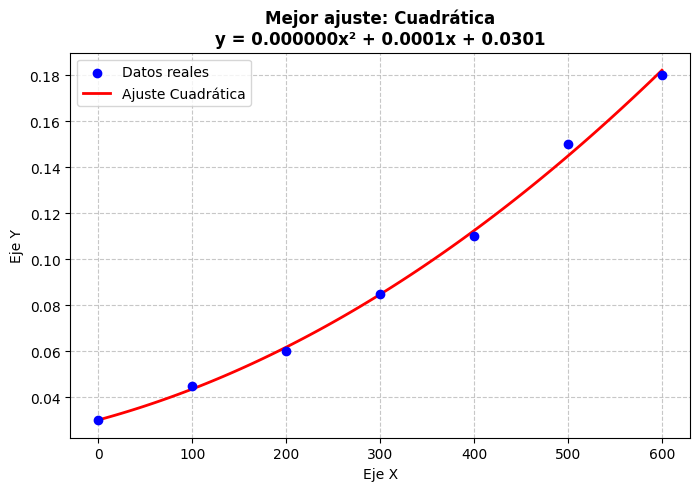

 El mejor modelo es: Cuadrática
 Ecuación: y = 0.000000x² + 0.0001x + 0.0301

 R^2 para cada modelo:
  - Lineal: 0.9720
  - Cuadrática: 0.9978
  - Exponencial: -inf


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings

# 1. Definimos las funciones matemáticas
def funcion_lineal(x, a, b):
    return a * x + b

def funcion_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c

def funcion_exponencial(x, a, b):
    return a * np.exp(b * x)

def calcular_r2(y_real, y_predicho):
    residuos = y_real - y_predicho
    suma_cuadrados_totales = np.sum((y_real - np.mean(y_real))**2)
    if suma_cuadrados_totales == 0: return 1.0
    return 1 - (np.sum(residuos**2) / suma_cuadrados_totales)

# Función para formatear la ecuación matemáticamente
def generar_ecuacion(nombre_modelo, coeficientes):
    if nombre_modelo == "Lineal":
        a, b = coeficientes
        return f"y = {a:.4f}x {'+' if b >= 0 else '-'} {abs(b):.4f}"
    
    elif nombre_modelo == "Cuadrática":
        a, b, c = coeficientes
        signo_b = '+' if b >= 0 else '-'
        signo_c = '+' if c >= 0 else '-'
        return f"y = {a:.6f}x² {signo_b} {abs(b):.4f}x {signo_c} {abs(c):.4f}"
    
    elif nombre_modelo == "Exponencial":
        a, b = coeficientes
        return f"y = {a:.4f} * e^({b:.4f}x)"
    
    return "Ecuación no disponible"

# 2. Función principal modificada
def analizar_y_graficar_datos(lista_x, lista_y):
    x = np.array(lista_x, dtype=float)
    y = np.array(lista_y, dtype=float)
    
    modelos = {
        "Lineal": funcion_lineal,
        "Cuadrática": funcion_cuadratica,
        "Exponencial": funcion_exponencial
    }
    
    resultados_r2 = {}
    mejor_modelo = None
    mejor_r2 = -float('inf')
    mejores_coeficientes = None
    mejor_funcion = None
    
    warnings.filterwarnings('ignore')
    
    for nombre, funcion in modelos.items():
        try:
            # Encontramos los coeficientes (popt)
            popt, _ = curve_fit(funcion, x, y, maxfev=10000)
            y_predicho = funcion(x, *popt)
            r2 = calcular_r2(y, y_predicho)
            resultados_r2[nombre] = r2
            
            # Guardamos el mejor modelo y sus coeficientes
            if r2 > mejor_r2:
                mejor_r2 = r2
                mejor_modelo = nombre
                mejores_coeficientes = popt
                mejor_funcion = funcion
                
        except Exception as e:
            resultados_r2[nombre] = "Error"
            
    warnings.filterwarnings('default')
    
    # Obtenemos la ecuación en texto
    ecuacion_texto = generar_ecuacion(mejor_modelo, mejores_coeficientes)
    
    # --- 3. SECCIÓN DE GRAFICADO ---
    plt.figure(figsize=(8, 5))
    
    # Graficamos los datos originales (Puntos)
    plt.scatter(x, y, color='blue', label='Datos reales', zorder=5)
    
    # Creamos un rango de X suave para dibujar la curva
    # Tomamos 100 puntos entre el valor mínimo y máximo de X
    x_suave = np.linspace(min(x), max(x), 100)
    y_suave = mejor_funcion(x_suave, *mejores_coeficientes)
    
    # Graficamos la curva de ajuste
    plt.plot(x_suave, y_suave, color='red', label=f'Ajuste {mejor_modelo}', linewidth=2)
    
    # Configuramos detalles del gráfico
    plt.title(f"Mejor ajuste: {mejor_modelo}\n{ecuacion_texto}", fontsize=12, fontweight='bold')
    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Mostramos el gráfico
    plt.show()
    
    return mejor_modelo, ecuacion_texto, resultados_r2


# Datos de prueba (Una función exponencial con un poco de "ruido")
datos_x = [0, 100, 200, 300, 400, 500, 600]
datos_y = [0.03, 0.045, 0.060, 0.085, 0.11, 0.15, 0.18]

mejor_ajuste, ecuacion, detalles = analizar_y_graficar_datos(datos_x, datos_y)

print(f" El mejor modelo es: {mejor_ajuste}")
print(f" Ecuación: {ecuacion}")
print("\n R^2 para cada modelo:")
for modelo, r2 in detalles.items():
    if isinstance(r2, float):
        print(f"  - {modelo}: {r2:.4f}")
    else:
        print(f"  - {modelo}: {r2}")

Y para el valor promedio:

In [11]:
mis_datos = [0.03, 0.045, 0.060, 0.085, 0.11, 0.15, 0.18]

# 2. Verificamos que la lista no esté vacía para evitar errores de división por cero
if len(mis_datos) > 0:
    # sum() suma todos los números, len() cuenta cuántos números hay
    promedio = sum(mis_datos) / len(mis_datos)
    
    print(f"Los datos son: {mis_datos}")
    print(f"El valor promedio es: {promedio:.2f}")
else:
    print("La lista está vacía, no se puede calcular el promedio.")

Los datos son: [0.03, 0.045, 0.06, 0.085, 0.11, 0.15, 0.18]
El valor promedio es: 0.09


Se puede observar que con un ajuste lineal es suficientemente aproximado. Con todos estos datos podemos tener las ecuaciones con valores promedio, y la que varía con la temperatura.
$$\frac{\partial{T_3}}{\partial{t}}=\frac{2\cdot k_{fc}\cdot A_{fc(prom)}}{\rho_{fc}\cdot A_{fc(prom)}\cdot\Delta x_{fc}^2\cdot c_{fc} + \rho_{lr}\cdot A_{lr(prom)}\cdot \Delta x_{lr}\cdot \Delta x_{fc}\cdot c_{lr}}(T_2-T_3)-\frac{2\cdot k_{lr}\cdot A_{lr(prom)}}{\rho_{fc}\cdot A_{fc(prom)}\cdot\Delta x_{fc}\cdot\Delta x_{lr}\cdot c_{fc} + \rho_{lr}\cdot A_{lr(prom)}\cdot \Delta x_{lr}^2\cdot c_{lr}}(T_3-T_4)$$

Los datos de la densidad y el calor específico de la lana de roca fueron extraidos de [figshare.unimelb.edu.au](https://figshare.unimelb.edu.au/ndownloader/files/18745982) y de los documentos de compra del material.

$\rho_{fc}=260\text{ kg}\text{ m}^{-3}$, Densidad de la fibra cerámica.\
$A_{fc(prom)}=0.28\text{ m}^2$, Area promedio del material dentro el nodo examinado, por parte de la fibra cerámica.\
$\Delta x_{fc}=0.020\text{ m}$, Espesor de la fibra cerámica.\
$c_{fc}=1246\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, Calor específico de la fibra cerámica.\
$\rho_{lr}=100\text{ kg}\text{ m}^{-3}$, Densidad de la lana de roca.\
$A_{lr(prom)}=0.40\text{ m}^2$, Area promedio del material dentro el nodo examinado, por parte de la lana de roca.\
$\Delta x_{lr}=0.020\text{ m}$, Espesor de la lana de roca por nodo.\
$c_{lr}=840\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, Calor específico de la fibra cerámica.\
$k_{fc(prom)}=0.19\text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica promedio de la fibra cerámica.\
$k_{fc}(T)=0.0002T+0.0160 \text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica en función de la temperatura del ladrillo refractario aislante.\
$k_{lr(prom)}=0.09\text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica promedio de la lana de roca.\
$k_{lr}(T)=0.0001T+0.0301 \text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica en función de la temperatura del ladrillo refractario aislante.

Con valores promedio:
$$\frac{\partial{T_3}}{\partial{t}}=0.0021(T_2-T_3)-0.0014(T_3-T_4)$$
Con la conductividad en función de la temperatura:
$$\frac{\partial{T_3}}{\partial{t}}=0.0113\cdot k_{cf}(T)(T_2-T_3)-0.0161\cdot k_{lr}(T)(T_3-T_4)$$
$$k_{fc}(T)=0.0002T+0.0160$$
$$k_{lr}(T)=0.0001T+0.0301$$

### Nodo 4 (Centro de la capa de lana de roca de 4cm)

La ecuación que describe este nodo es:
$$(m_{lr}\cdot c_{lr} + m_{lr-ext}\cdot c_{lr-ext})\frac{\partial{T_4}}{\partial{t}}=\frac{k_{lr}\cdot A_{lr(prom)}}{\Delta x_{lr}}(T_3-T_4)-\frac{k_{lr-ext}\cdot A_{lr-ext(prom)}}{\Delta x_{lr-ext}}(T_4-T_5)$$
$$\frac{\partial{T_4}}{\partial{t}}=\frac{k_{lr}\cdot A_{lr(prom)}}{\Delta x_{lr}(\rho_{lr}\cdot A_{lr(prom)}\cdot\Delta x_{lr}/2\cdot c_{lr}+ \rho_{lr-ext}\cdot A_{lr-ext(prom)}\cdot \Delta x_{lr-ext}/2\cdot c_{lr-ext})}(T_3-T_4)-\frac{k_{lr-ext}\cdot A_{lr-ext(prom)}}{\Delta x_{lr-ext}(\rho_{lr}\cdot A_{lr(prom)}\cdot\Delta x_{lr}/2\cdot c_{lr} + \rho_{lr-ext}\cdot A_{lr-ext(prom)}\cdot\Delta x_{lr-ext}/2\cdot c_{lr-ext})}(T_4-T_5)$$

Si las siguientes propiedades son iguales: $\rho_{lr}$ y $\rho_{lr-ext}$, $\Delta x_{lr}$ y $\Delta x_{lr-ext}$, $c_{lr}$ y $c_{lr-ext}$ y $k_{lr}$ y $k_{lr-ext}$
$$\frac{\partial{T_4}}{\partial{t}}=\frac{2\cdot k_{lr}\cdot A_{lr(prom)}}{\rho_{lr}\cdot\Delta x_{lr}^2\cdot c_{lr}(A_{lr(prom)} + A_{lr-ext(prom)})}(T_3-T_4)-\frac{2\cdot k_{lr}\cdot A_{lr-ext(prom)}}{\rho_{lr}\cdot\Delta x_{lr}^2\cdot c_{lr}(A_{lr(prom)} + A_{lr-ext(prom)})}(T_4-T_5)$$

Calculamos las areas promedio para la lana de roca exterior, ya que la lana de roca interior ya fue calculado:
$$A_{i}=4(0.26\cdot 0.32) + 2(0.26\cdot 0.26)=0.47\text{ m}^2$$
$$A_{o}=4(0.30\cdot 0.36) + 2(0.30\cdot 0.30)=0.61\text{ m}^2$$
$$A_{lr-ext(prom)}=\sqrt{A_i\cdot A_o}=\sqrt{0.47\cdot 0.61}=0.54\text{ m}^2$$

De la anterior sección sabemos la variación de conductividad de la lana de roca y sus propiedades, por tanto:
$$\frac{\partial{T_4}}{\partial{t}}=\frac{2\cdot k_{lr}\cdot A_{lr(prom)}}{\rho_{lr}\cdot\Delta x_{lr}^2\cdot c_{lr}(A_{lr(prom)} + A_{lr-ext(prom)})}(T_3-T_4)-\frac{2\cdot k_{lr}\cdot A_{lr-ext(prom)}}{\rho_{lr}\cdot\Delta x_{lr}^2\cdot c_{lr}(A_{lr(prom)} + A_{lr-ext(prom)})}(T_4-T_5)$$

$\rho_{lr}=100\text{ kg}\text{ m}^{-3}$, Densidad de la lana de roca.\
$\Delta x_{lr}=0.020\text{ m}$, Espesor de la lana de roca por nodo.\
$c_{lr}=840\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, Calor específico de la fibra cerámica.\
$A_{lr(prom)}=0.40\text{ m}^2$, Area promedio del material dentro el nodo examinado, por parte de la lana de roca.\
$A_{lr-ext(prom)}=0.54\text{ m}^2$, Area promedio de la capa exterior de la lana de roca.\
$k_{lr(prom)}=0.09\text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica promedio de la lana de roca.\
$k_{lr}(T)=0.0001T+0.0301 \text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica en función de la temperatura del ladrillo refractario aislante.

Con los valores promedio:
$$\frac{\partial{T_4}}{\partial{t}}=0.0023(T_3-T_4)-0.0031(T_4-T_5)$$

Con la conductividad en función de la temperatura:
$$\frac{\partial{T_4}}{\partial{t}}=0.0253\cdot k_{lr}(T)(T_3-T_4)-0.0342\cdot k_{lr}(T)(T_4-T_5)$$
$$k_{lr}(T)=0.0001T+0.0301$$

### Nodo 5 (Superficie exterior del horno-lana de roca)

En la superficie exterior se tiene una plancha de acero que contiene los elementos aislantes, pero esta al ser tan delgada y buen conductor de calor, se desprecia en el modelado y solo se toma en cuenta su efecto en la disipación por radiación.
La ecuación que describe este nodo es:
$$m_{lr-ext}\cdot c_{lr-ext}\frac{\partial{T_5}}{\partial{t}}=\frac{k_{lr-ext}\cdot A_{lr-ext(prom)}}{\Delta x_{lr-ext}}(T_4-T_5)-h_{ext}\cdot A_{lr-ext}(T_5-T_{\infty})-\varepsilon_{ac}\cdot\sigma\cdot A_{lr-ext}(T_5^4-T_{\infty}^4)$$
$$\frac{\partial{T_5}}{\partial{t}}=\frac{2\cdot k_{lr}\cdot A_{lr-ext(prom)}}{\rho_{lr}\cdot A_{lr-ext(prom)}\cdot c_{lr}\cdot\Delta x_{lr}^2}(T_4-T_5)-\frac{2\cdot h_{ext}\cdot A_{lr-ext}}{\rho_{lr}\cdot A_{lr-ext(prom)}\cdot c_{lr}\cdot\Delta x_{lr}}(T_5-T_{\infty})-\frac{2\cdot\varepsilon_{ac}\cdot\sigma\cdot A_{lr-ext}}{\rho_{lr}\cdot A_{lr-ext(prom)}\cdot c_{lr}\cdot\Delta x_{lr}}(T_5^4-T_{\infty}^4)$$

Teniendo en cuenta que $k_{lr}=k_{lr-ext}$, $c_{lr}=c_{lr-ext}$ y $\Delta x_{lr}=\Delta x_{lr-ext}$ 

Calculamos el area externa, para las transferenias de calor por convección y radiación en el exterior del horno.
$$A_{lr-ext}=4(0.30\cdot0.36) + 2(0.30\cdot0.30)=0.61\text{ m}^2$$

Los datos necesarios y la variación de la conductividad de la lana de roca, ya fueron calculados, por tanto:

$$\frac{\partial{T_5}}{\partial{t}}=\frac{2\cdot k_{lr}}{\rho_{lr}\cdot c_{lr}\cdot\Delta x_{lr}^2}(T_4-T_5)-\frac{2\cdot h_{ext}\cdot A_{lr-ext}}{\rho_{lr}\cdot A_{lr-ext(prom)}\cdot c_{lr}\cdot\Delta x_{lr}}(T_5-T_{\infty})-\frac{2\cdot\varepsilon_{ac}\cdot\sigma\cdot A_{lr-ext}}{\rho_{lr}\cdot A_{lr-ext(prom)}\cdot c_{lr}\cdot\Delta x_{lr}}(T_5^4-T_{\infty}^4)$$

Donde:\
$\rho_{lr}=100\text{ kg}\text{ m}^{-3}$, Densidad de la lana de roca.\
$c_{lr}=840\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, Calor específico de la fibra cerámica.\
$\Delta x_{lr}=0.020\text{ m}$, Espesor de la lana de roca por nodo.\
$h_{ext}=15\text{ W m}^{-2}\text{ K}^{-1}$, Coeficiente de convección natural promedio del aire. (Cengel, 2012).\
$A_{lr-ext(prom)}=0.54\text{ m}^2$, Area promedio de la capa exterior de la lana de roca.\
$A_{lr-ext}=0.61\text{ m}^2$, Area exterior del horno.\
$\varepsilon_{ac}=0.26$, Emisividad del superficie de acero comercial. (Cengel, 2012).\
$\sigma= 5.67 \times 10^{-8} \text{ W m}^{-2} \text{ K}^{-4}$, Constante de Stefan-Boltzmann.\
$k_{lr(prom)}=0.09\text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica promedio de la lana de roca.\
$k_{lr}(T)=0.0001T+0.0301 \text{ W m}^{-1}\text{ K}^{-1}$, Conductividad térmica en función de la temperatura del ladrillo refractario aislante.

Con los valores promedio:
$$\frac{\partial{T_5}}{\partial{t}}=0.0054(T_4-T_5)-0.0202(T_5-T_{\infty})-1.98\times10^{-11}(T_5^4-T_{\infty}^4)$$

Con la conductividad en función de la temperatura:
$$\frac{\partial{T_5}}{\partial{t}}=0.0595\cdot k_{lr}(T)(T_4-T_5)-0.0202(T_5-T_{\infty})-1.98\times10^{-11}(T_5^4-T_{\infty}^4)$$
$$k_{lr}(T)=0.0001T+0.0301$$


### Aporte de radiación vs. convección 
El siguiente script describe como la radiación va creciendo en el aporte de calor, en comparación con la convección que va reduciendo. Es por esta razon, que solo se toma en cuenta la radiación para el modeledo matemático del horno.

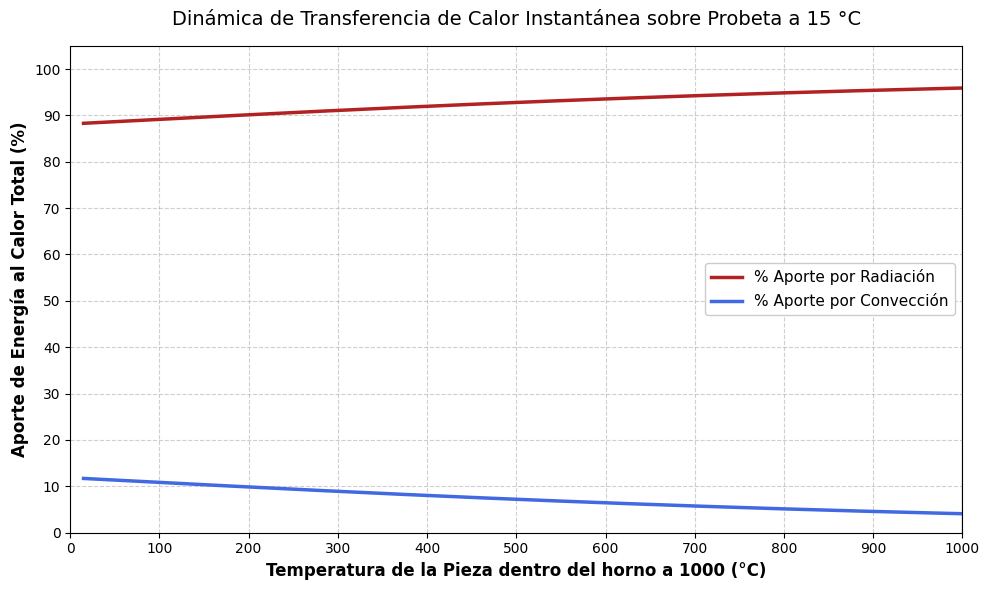

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Parámetros Físicos del Caso de Estudio
# ==========================================
h = 15.0                 # Coeficiente de convección libre (W/m^2K)
epsilon = 0.75           # Emisividad de la probeta de acero A36
sigma = 5.67e-8          # Constante de Stefan-Boltzmann (W/m^2K^4)
A_p = 0.0034             # Área superficial de la probeta (m^2)

T_horno_C = 1000.0         # Temperatura de la pieza al entrar al horno (°C)
T_horno_K = T_horno_C + 273.15

# Vector de temperatura del horno (Empezamos en 26°C para evitar 0/0)
T_pieza_C = np.linspace(15, 999, 500)
T_pieza_K = T_pieza_C + 273.15

# ==========================================
# 2. Cálculo de Transferencia de Calor Instantánea
# ==========================================
# Flujo de calor por Convección (W)
q_conv = h * A_p * (T_horno_K - T_pieza_K)

# Flujo de calor por Radiación (W)
q_rad = epsilon * sigma * A_p * (T_horno_K**4 - T_pieza_K**4)

# Energía Total y Porcentajes
q_total = q_conv + q_rad
porcentaje_conv = (q_conv / q_total) * 100
porcentaje_rad = (q_rad / q_total) * 100

# ==========================================
# 3. Graficado Profesional
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

# Estilo para tesis (Fondo blanco, líneas claras)
plt.style.use('default')
ax1.grid(True, linestyle='--', alpha=0.6)
# Graficar Porcentajes
line_rad, = ax1.plot(T_pieza_C, porcentaje_rad, color='firebrick', linewidth=2.5, 
                     label='% Aporte por Radiación')
line_conv, = ax1.plot(T_pieza_C, porcentaje_conv, color='royalblue', linewidth=2.5, 
                      label='% Aporte por Convección')

# Formato del Eje Y (Porcentaje)
ax1.set_ylabel('Aporte de Energía al Calor Total (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.set_yticks(np.arange(0, 110, 10))

# Formato del Eje X (Temperatura)
ax1.set_xlabel('Temperatura de la Pieza dentro del horno a 1000 (°C)', fontsize=12, fontweight='bold')
ax1.set_xlim(25, 1000)
ax1.set_xticks(np.arange(0, 1100, 100))

# Título y Leyenda
plt.title('Dinámica de Transferencia de Calor Instantánea sobre Probeta a 15 °C', 
          fontsize=14, pad=15)
ax1.legend(loc='center right', fontsize=11, framealpha=1.0)

# Rellenar el área entre las curvas para mayor impacto visual
ax1.fill_between(T_horno_C, porcentaje_rad, 0, color='firebrick', alpha=0.1)
ax1.fill_between(T_horno_C, porcentaje_conv, 0, color='royalblue', alpha=0.1)

plt.tight_layout()
plt.show()